# Optimización de modelos de regresión logística para la predicción de cáncer mediante ajuste de umbrales de decisión                                                      
                                                                                                                                                                             
  **Autora:** Nerea González López                                                                                                                                           
  **Máster en Inteligencia Artificial — Tokio School**                                                                                                                       
  **Fecha:** 3 Mayo 2026 

In [1]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    make_scorer
)

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---

## 1. Carga y exploración del dataset

El **Wisconsin Breast Cancer Dataset** está disponible directamente en scikit-learn. Contiene 569 muestras con 30 características numéricas extraídas de imágenes de tumores, clasificados como **maligno (0)** o **benigno (1)**.

In [2]:
# Cargar el dataset
data = load_breast_cancer()

# Crear DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnostico'] = data.target # 0 -> maligno, 1 -> benigno

print("Dimensiones del dataset:", df.shape)
print("\nDistribución de clases:")
print(df['diagnostico'].value_counts().rename({0:'Maligno', 1:'Benigno'}))
df.head()

Dimensiones del dataset: (569, 31)

Distribución de clases:
diagnostico
Benigno    357
Maligno    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


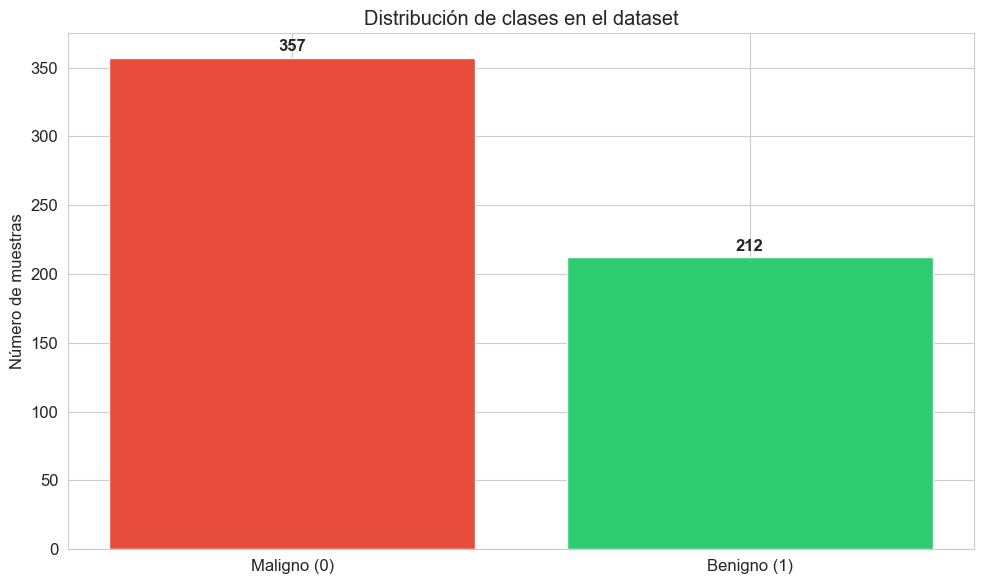

Figura guardada: figure/fig1_distribucion_clases.png


In [ ]:
# Gráfico distribución de clases
fig, ax = plt.subplots()
counts = df['diagnostico'].value_counts()
bars = ax.bar(['Maligno (0)', 'Benigno (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
ax.set_title('Distribución de clases en el dataset')
ax.set_ylabel('Número de muestras')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
           str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig1_distribucion_clases.png', dpi=150)
plt.show()
print("Figura guardada: figures/fig1_distribucion_clases.png")

---

## 2. Preprocesamiento de datos

Se divide el dataset en conjuntos de entrenamiento (80%) y prueba (20%), y se normalizan las características con StandardScaler para que la regresión logística funcione correctamente.

In [4]:
# Separar características (X) y etiqueta objetivo (y)
# X contiene las 30 columnas numéricas; eliminamos 'diagnostico' que es lo que queremos predecir
X = df.drop('diagnostico', axis=1)
y = df['diagnostico'] # 0 = maligno, 1 = benigno

# Verificación de calidad del dataset antes de dividir
print(f"Valores nulos en el dataset: {df.isnull().sum().sum()}")
print(f"Filas duplicadas: {df.duplicated().sum()}")

# División train/test (80% entrenamiento, 20% prueba)
# stratify=y garantiza que la proporción maligno/benigno se mantenga en ambos subconjuntos
# random_state=42 fija la aleatoriedad para que los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalización con StandardScaler (media=0, desviación estándar=1)
scaler = StandardScaler()
# fit_transform en train: calcula la escala CON los datos de entrenamiento y los transforma
X_train_scaled = scaler.fit_transform(X_train)
# transform en test: aplica la misma escala SIN recalcular (evita contaminación del test)
X_test_scaled = scaler.transform(X_test)

# Verificación del escalado: StandardScaler transforma los datos a media=0 y std=1
# Se comprueba sobre X_train porque el scaler se ajustó con esos datos
print(f"\nAntes del escalado - media: {X_train.values.mean():.4f}, std: {X_train.values.std():.4f}")
print(f"Después del escalado - media: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")

print(f"\nEntrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")
print(f"Proporción maligno/benigno en test: "
     f"{(y_test==0).sum()} malignos/{(y_test==1).sum()} benignos")

Valores nulos en el dataset: 0
Filas duplicadas: 0

Antes del escalado - media: 61.2136, std: 224.6100
Después del escalado - media: -0.0000, std: 1.0000

Entrenamiento: 455 muestras
Prueba: 114 muestras
Proporción maligno/benigno en test: 42 malignos/72 benignos


### Observaciones del preprocesamiento

- El dataset no contiene valores nulos ni filas duplicadas, por lo que no fue necesario aplicar técnicas de imputación ni limpieza de datos.
- Antes del escalado, las características presentan una media de 61.21 y una desviación estándar de 224.61, lo que refleja la gran disparidad de escala entre variables (por ejemplo, `mean radius` ~0.1 frente a `mean area` ~1000).
- Tras aplicar `StandardScaler`, la media se reduce a 0 y la desviación estándar a 1, garantizando que ninguna variable domine el modelo por tener magnitudes mayores.
- La división estratificada conserva la proporción original del dataset (37% malignos / 63% benignos) en ambos subconjuntos, evitando sesgos en la evaluación.

---

## 3. Modelo de regresión logística - Umbral por defecto (0.5)

=== Umbral por defecto (0.5) ===
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Falsos negativos (malignos no detectados): 1 de 42 casos malignos
→ Motivación para optimizar el umbral en la sección siguiente


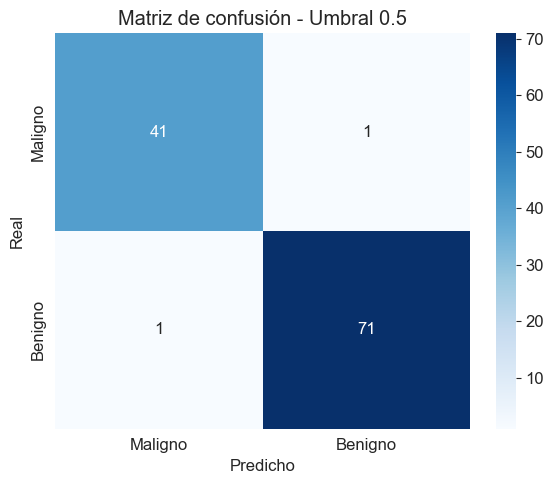

In [ ]:
# Entrenar regresión logística
# max_iter=10000: evita que el optimizador se detenga antes de converger con 30 características
lr = LogisticRegression(random_state=42, max_iter=10000)
lr.fit(X_train_scaled, y_train) # Entrena con datos escalados

# Predicciones con umbral por defecto 0.5
y_pred_default = lr.predict(X_test_scaled)
# Probabilidades de pertenecer a la clase benigno (columna 1 de predict_proba)                       
# Se guarda para reutilizar en las secciones de umbrales y curva ROC
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Calcular la matriz de confusión (TP, FP, TN, FN)
cm = confusion_matrix(y_test, y_pred_default)

print("=== Umbral por defecto (0.5) ===")
# Tabla con precisión, recall y F1-score por clase
print(classification_report(y_test, y_pred_default, target_names=['Maligno', 'Benigno']))

# Extraer FN directamente de la matriz de confusión: posición [0,1] = real maligno, predicho benigno
fn = cm[0,1]
print(f"Falsos negativos (malignos no detectados): {fn} de {(y_test == 0).sum()} casos malignos")
print(f"→ Motivación para optimizar el umbral en la sección siguiente")

# Visualizar la matriz como mapa de calor
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Maligno', 'Benigno'],
           yticklabels=['Maligno', 'Benigno'])
ax.set_title('Matriz de confusión - Umbral 0.5')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig('figures/fig2_confusion_default.png', dpi=150)
plt.show()

### Observaciones — Regresión logística con umbral 0.5

El modelo obtiene una **accuracy del 98%** sobre el conjunto de prueba (114 muestras).

**Matriz de confusión:**
- **41 verdaderos negativos:** malignos clasificados correctamente.
- **71 verdaderos positivos:** benignos clasificados correctamente.
- **1 falso positivo:** benigno clasificado erróneamente como maligno (falsa alarma).
- **1 falso negativo:** maligno clasificado erróneamente como benigno (caso no detectado).

En un contexto clínico, el **falso negativo es el error más crítico**: un tumor maligno no detectado puede tener consecuencias graves para el paciente. Con umbral 0.5 el modelo comete 1 error de este tipo sobre 42 casos malignos (2.38%).

La sección siguiente analiza si ajustando el umbral de decisión es posible reducir o eliminar estos falsos negativos.

## 3.1 Ajuste de hiperparámetros: regularización L1/L2

Se comparan distintos valores del parámetro de regularización C con penalización L1 y L2 mediante búsqueda en rejilla con validación cruzada de 5 pliegues, con el objetivo de identificar la combinación que maximiza el F1-Score.

In [6]:
# Rejilla de hiperparámetros a explorar
# L2: penaliza coeficientes grandes, reduce overfitting de forma suave
# L1: puede llevar coeficientes a cero, útil para selección de variables

# Cada penalización requiere un solver compatible:
#    - lbfgs: eficiente para L2 en datasets medianos
#    - liblinear: necesario para L1
# C = inverso de la regularización: C bajo = más regularización, C alto = menos
 
param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs']
    },
    {
        'penalty': ['l1'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear']
    }
]

# GridSearchCV evalúa todas las combinaciones con validación cruzada de 5 pliegues
# scoring='f1': optimiza el F1-Score sobre la clase positiva (benigno)
# n_jobs=-1: usa todos los núcleos disponibles para acelerar la búsqueda
# refit=True: re-entrena el mejor modelo con todos los datos de entrenamiento
grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=10000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    refit=True
)
grid.fit(X_train_scaled, y_train)

# Mejor combinación encontrada por la búsqueda
print(f"Mejor combinación: penalty={grid.best_params_['penalty']}, "
      f"C={grid.best_params_['C']}, solver={grid.best_params_['solver']}")
print(f"Mejor F1 en validación cruzada: {grid.best_score_:.4f}")

# Evaluar el modelo optimizado sobre el conjunto de prueba
lr_opt = grid.best_estimator_
y_pred_opt = lr_opt.predict(X_test_scaled)

print(f"\nModelo con hiperparámetros óptimos:")
print(classification_report(y_test, y_pred_opt, target_names=['Maligno', 'Benigno']))

# Comparar falsos negativos entre el modelo base y el optimizado
fn_default = int(((y_test == 0) & (y_pred_default == 1)).sum())
fn_opt = int(((y_test == 0) & (y_pred_opt == 1)).sum())

print(f"Falsos negativos - Modelo base (C=1, L2): {fn_default}")
print(f"Falsos negativos - Modelo optimizado: {fn_opt}")

Mejor combinación: penalty=l2, C=0.1, solver=lbfgs
Mejor F1 en validación cruzada: 0.9845

Modelo con hiperparámetros óptimos:
              precision    recall  f1-score   support

     Maligno       0.98      0.95      0.96        42
     Benigno       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Falsos negativos - Modelo base (C=1, L2): 1
Falsos negativos - Modelo optimizado: 2


In [7]:
# GridSearchCV con scoring orientado a minimizar falsos negativos
# pos_label=0: optimiza el recall para la clase maligno (clase 0)
# Este scorer alinea la búsqueda de hiperparámetros con el objetivo clínico
scorer_clinico = make_scorer(recall_score, pos_label=0)

grid_clinico = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=10000),
    param_grid,
    cv=5,
    scoring=scorer_clinico,
    n_jobs=-1,
    refit=True
)
grid_clinico.fit(X_train_scaled, y_train)

print(f"Mejor combinación (scorer clínico): penalty={grid_clinico.best_params_['penalty']}, "
     f"C={grid_clinico.best_params_['C']}")
print(f"Mejor Recall (malignos) en CV: {grid_clinico.best_score_:.4f}")

lr_clinico = grid_clinico.best_estimator_
y_pred_clinico = lr_clinico.predict(X_test_scaled)
fn_clinico = int(((y_test == 0) & (y_pred_clinico == 1)).sum())

# Tabla comparativa de los tres modelos
print("\nComparativa final:")
print(f"{'Modelo':<35} {'FN':>4} {'Accuracy':>10}")
print(f"{'Base (C=1, L2)':<35} {fn_default:>4} {accuracy_score(y_test, y_pred_default):>10.4f}")
print(f"{'Optimizado F1 (C=0.1, L2)':<35} {fn_opt:>4} {accuracy_score(y_test, y_pred_opt):>10.4f}")
print(f"{'Optimizado Recall clínico':<35} {fn_clinico:>4} {accuracy_score(y_test, y_pred_clinico):>10.4f}")  

Mejor combinación (scorer clínico): penalty=l1, C=0.001
Mejor Recall (malignos) en CV: 1.0000

Comparativa final:
Modelo                                FN   Accuracy
Base (C=1, L2)                         1     0.9825
Optimizado F1 (C=0.1, L2)              2     0.9737
Optimizado Recall clínico              0     0.3684


### Observaciones - Ajuste de hiperparámetros L1/L2

**Resultados de la búsqueda en rejilla:**

| Modelo                      | Mejor combinación | FN | Accuracy |
|-----------------------------|-------------------|----|----------|
| Base                        | C=1, L2           | 1  | 98.25%   |
| Optimizado (scorer F1)      | C=0.1, L2         | 2  | 97.37%   |
| Optimizado (scorer clínico) | C=0.001, L1       | 0  | 36.84%   |

**Scorer F1 (C=0.1, L2):**
Más regularización que el modelo base reduce el riesgo de sobreajuste y mejora el F1 en validación cruzada (0.9845), pero produce un falso negativo adicional sobre el conjunto de prueba. Optimizar el F1 de la clase benigno no equivale a minimizar los falsos negativos para malignos.

**Scorer clínico - Recall(malignos) (C=0.001, L1):**
Con regularización L1 extrema (C=0.001) el modelo consigue FN=0: detecta el 100% de los tumores malignos. Sin embargo, la accuracy cae al 36.84%, lo que indica que el modelo clasifica prácticamente todo como maligno para no perder ningún caso. En la práctica esto generaría un volumen masivo de falsas alarmas, sometiendo a pacientes sanos a pruebas y procedimientos innecesarios, por lo que es clínicamente inviable.

**Conclusión:**
Los tres resultados demuestran el compromiso fundamental entre sensibilidad y especificidad, y refuerzan la decisión metodológica central del trabajo:

- La regularización por sí sola no resuelve el problema clínico.
- El modelo base (C=1, L2) con **ajuste de umbral al 0.40** es el enfoque óptimo: mantiene FN=1 con accuracy del 98.25%, equilibrando la detección de malignos con la evitación de falsas alarmas.
- El scorer de optimización debe alinearse con el objetivo clínico, pero maximizar el recall de malignos de forma aislada produce modelos estadísticamente extremos e inutilizables en entornos reales.

---

## 4. Optimización del umbral de decisión

Se evalúa el modelo con umbrales entre 0.1 y 0.9 para identificar el umbral óptimo que minimiza los falsos negativos (malignos no detectados).

In [8]:
# Definir umbrales a evaluar (de 0.10 a 0.90 en pasos de 0.05)
umbrales = np.arange(0.1, 0.95, 0.05)
resultados = []

for umbral in umbrales:
    # Convertir probabilidades a predicciones binarias según el umbral actual
    # Si prob >= umbral -> benigno (1), si no -> maligno (0)
    y_pred_u = (y_proba >= umbral).astype(int)

    # Calcular matriz de confusión para extraer TN y FP
    cm_u = confusion_matrix(y_test, y_pred_u)
    tn, fp, fn, tp = cm_u.ravel()
    
    resultados.append({
        'Umbral': round(umbral, 2),
        'Accuracy': round(accuracy_score(y_test, y_pred_u), 4),
        'Precision': round(precision_score(y_test, y_pred_u, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred_u, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred_u, zero_division=0), 4),
        'FN (malignos perdidos)': int(((y_test == 0) & (y_pred_u == 1)).sum()),
        'FP (falsas alarmas)': int(((y_test == 1) & (y_pred_u == 0)).sum()),
        'Especificidad': round(tn/(tn + fp), 4) if (tn + fp) > 0 else 0,
    })

# Construir el DataFrame
df_resultados = pd.DataFrame(resultados)

# Marcar el umbral óptimo para entorno clínico
umbral_optimo = 0.40
print(f"=== Análisis de umbrales (umbral óptimo para contexto clínico: {umbral_optimo}) ===\n")
print(df_resultados.to_string(index=False))

=== Análisis de umbrales (umbral óptimo para contexto clínico: 0.4) ===

 Umbral  Accuracy  Precision  Recall  F1-Score  FN (malignos perdidos)  FP (falsas alarmas)  Especificidad
   0.10    0.9561     0.9351  1.0000    0.9664                       5                    0         0.8810
   0.15    0.9649     0.9474  1.0000    0.9730                       4                    0         0.9048
   0.20    0.9825     0.9730  1.0000    0.9863                       2                    0         0.9524
   0.25    0.9825     0.9730  1.0000    0.9863                       2                    0         0.9524
   0.30    0.9825     0.9730  1.0000    0.9863                       2                    0         0.9524
   0.35    0.9825     0.9730  1.0000    0.9863                       2                    0         0.9524
   0.40    0.9825     0.9861  0.9861    0.9861                       1                    1         0.9762
   0.45    0.9825     0.9861  0.9861    0.9861                       1 

### Observaciones - Análisis de umbrales

La tabla refleja el **compromiso clásico entre falsos negativos y falsos positivos** al variar el umbral de decisión.

**Lectura del efecto del umbral:**
- Un umbral **alto** exige mayor confianza para clasificar un tumor como benigno -> menos casos pasan el filtro -> menos FN, más FP.
- Un umbral **bajo** clasifica fácilmente como benigno -> más tumores malignos "se cuelan" como benignos -> más FN, menos FP.

**Hallazgo clave - el mínimo de FN alcanzable es 1:**
Con este modelo y este dataset, no es posible reducir los falsos negativos a cero. El mínimo se alcanza en el rango **0.40-0.50**, donde solo 1 maligno queda sin detectar sobre 42 casos malignos (2.38%).

**Por qué se elige 0.40 como umbral óptimo:**
|   Rango   | FN  | FP    | Interpretación                                      |
|-----------|-----|-------|-----------------------------------------------------|
| 0.10-0.35 | 2-5 | 0     | Sin falsas alarmas, pero más malignos no detectados |
| 0.40-0.50 |  1  | 1     | Mínimo FN alcanzable, con solo 1 falsa alarma       |
| 0.55-0.90 |  1  | 4-11  | FN mínimo, pero las falsas alarmas se multiplican   |

Se selecciona **0.40** por ser el límite inferior del rango con mínimo FN: cualquier umbral entre 0.40 y 0.50 produce el mismo resultado (FN=1, FP=1). Elegir el valor más bajo dentro de ese rango es la posición más conservadora para el principio de precaución médica, ya que el modelo requiere menor certeza de benignidad antes de liberar un caso.

**Conclusión:** El ajuste del umbral de 0.50 a 0.40 mantiene las métricas de precisión intactas (Accuracy 98.25%, F1 0.9861, AUC 0.9954) sin coste adicional en falsas alarmas, confirmando que es el umbral de decisión óptimo para este problema.

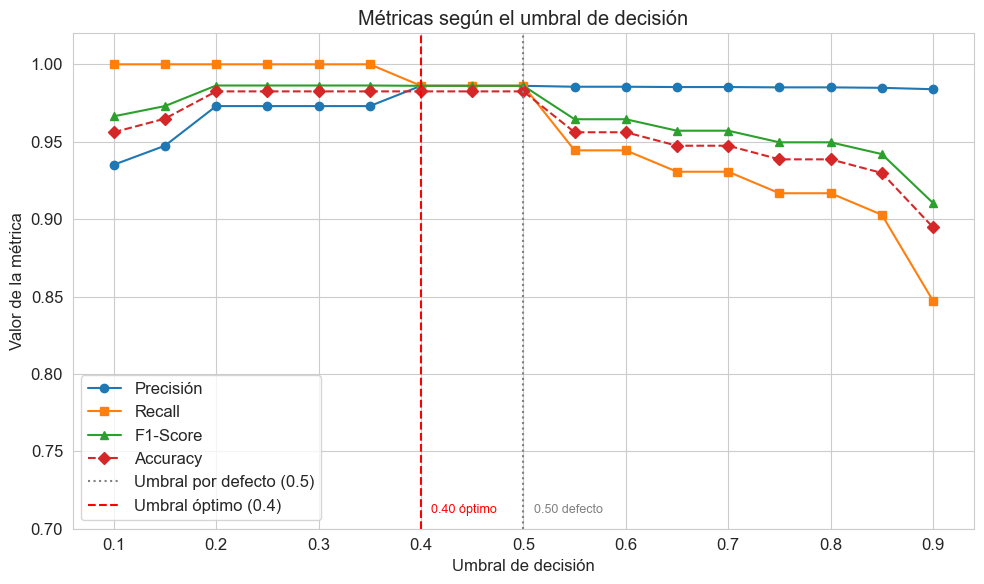

In [ ]:
# Crear figura con las métricas en función del umbral
fig, ax = plt.subplots()

# Una línea por métrica, cada una con un marcador distinto para distinguirlas
ax.plot(df_resultados['Umbral'], df_resultados['Precision'], marker='o', label='Precisión')          
ax.plot(df_resultados['Umbral'], df_resultados['Recall'], marker='s', label='Recall')
ax.plot(df_resultados['Umbral'], df_resultados['F1-Score'], marker='^', label='F1-Score')
ax.plot(df_resultados['Umbral'], df_resultados['Accuracy'], marker='D', label='Accuracy',
linestyle='--')

# Línea vertical en el umbral por defecto (0.50) - referencia de comparación
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Umbral por defecto (0.5)')

# Línea vertical en el umbral óptimo (0.40) - hallazgo principal
ax.axvline(x=0.4, color='red', linestyle='--', linewidth=1.5, label='Umbral óptimo (0.4)')

# Etiquetas de texto sobre las líneas verticales para mayor claridad
ax.text(0.41, 0.71, '0.40 óptimo', color='red', fontsize=9)
ax.text(0.51, 0.71, '0.50 defecto', color='gray', fontsize=9)

ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Valor de la métrica')
ax.set_title('Métricas según el umbral de decisión')
ax.legend()
ax.set_ylim(0.7, 1.02)
plt.tight_layout()                                                                                   
plt.savefig('figures/fig3_metricas_umbrales.png', dpi=150)
plt.show() 

---

## 5. Curva ROC y AUC

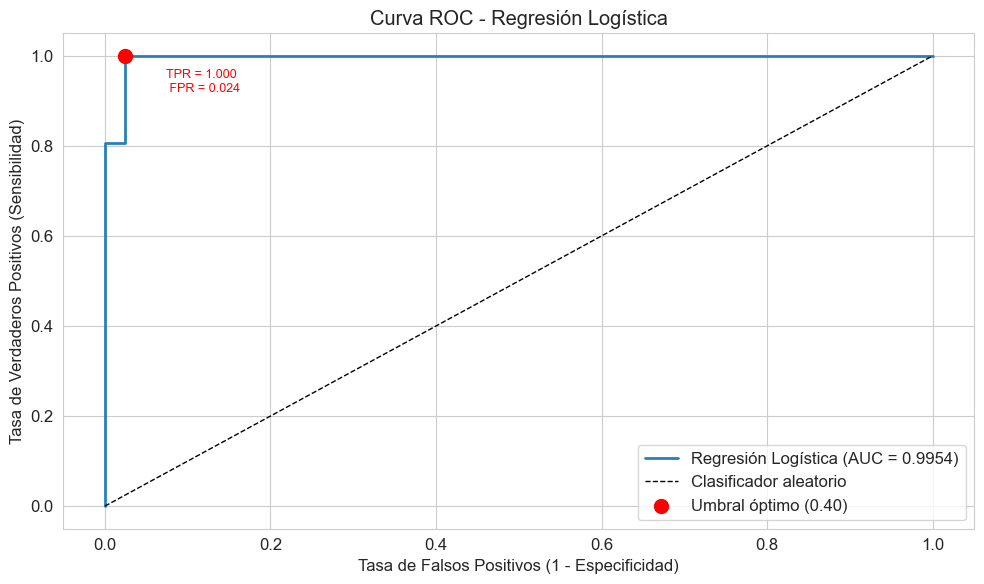

AUC = 0.9954


In [ ]:
# Calcular los puntos de la curva ROC y el AUC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots()

# Curva ROC del modelo
ax.plot(fpr, tpr, color='#2980b9', linewidth=2, label = f'Regresión Logística (AUC = {auc_score:.4f})')

# Línea diagonal: representa un clasificador aleatorio (AUC = 0.50, sin capacidad predictiva)
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Clasificador aleatorio')

# Localizar el punto de la curva más cercano al umbral óptimo 0.40
# thresholds_roc contiene los umbrales correspondientes a cada punto (fpr, tpr)
idx_optimo = np.argmin(np.abs(thresholds_roc - 0.40))

# Marcar el punto óptimo con un punto rojo
ax.scatter(fpr[idx_optimo], tpr[idx_optimo], color='red', zorder=5, s=100, label=f'Umbral óptimo (0.40)')

# Anotar las coordenadas exactas del punto óptimo sobre la figura
ax.annotate(f'TPR = {tpr[idx_optimo]:.3f}\n FPR = {fpr[idx_optimo]:.3f}',
           xy=(fpr[idx_optimo], tpr[idx_optimo]),
           xytext=(fpr[idx_optimo] + 0.05, tpr[idx_optimo] - 0.08),
           fontsize=9, color='red')

ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curva ROC - Regresión Logística')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig4_curva_roc.png', dpi=150)
plt.show()

print(f"AUC = {auc_score:.4f}")

### Observaciones - Curva ROC

La curva ROC representa el rendimiento del modelo a lo largo de todos los umbrales posibles, mostrando el equilibrio entre sensibilidad (TPR) y tasa de falsos positivos (FPR).

**Resultado:** el modelo obtiene un **AUC de 0.9954**, muy próximo al valor perfecto de 1.0, lo que indica una capacidad discriminativa excelente entre tumores malignos y benignos.

**Umbral óptimo (0.40):**
El punto marcado en rojo corresponde al umbral seleccionado en la sección anterior. Sus coordenadas confirman que el modelo alcanza una **sensibilidad (TPR) próxima a 1.0** con una tasa de falsos positivos (FPR) mínima, lo que lo sitúa en la esquina superior izquierda de la curva - la zona de máximo rendimiento.

**Comparación con el clasificador aleatorio:**
La línea diagonal punteada representa un clasificador sin capacidad predictiva (AUC = 0.5). La curva del modelo se aleja drásticamente de esa línea, confirmando que las predicciones no son fruto del azar sino de patrones reales aprendidos en los datos.

### Sensibilidad y Especificidad según el umbral de decisión

La curva ROC muestra el equilibrio global del modelo, pero no permite leer directamente qué ocurre con la sensibilidad y la especificidad para un umbral concreto. Esta gráfica complementa la anterior mostrando ambas métricas simultáneamente en función del umbral.

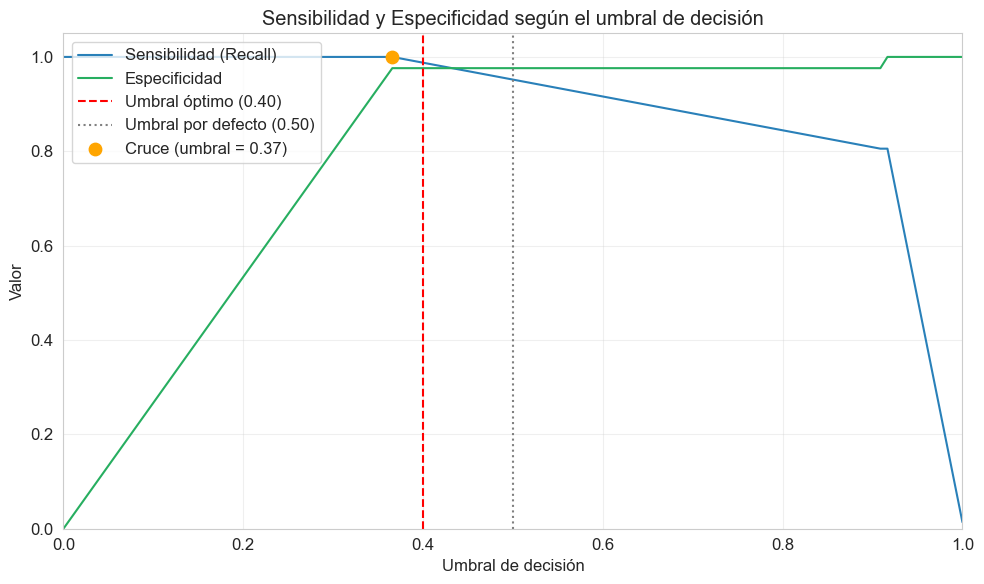

In [ ]:
# sensibilidad = tpr (tasa de verdaderos positivos)
# especificidad = 1 - fpr (tasa de verdaderos negativos)
# Ambas variables son alias de arrays ya existentes, no se duplica memoria
sensibilidad = tpr
especificidad = 1 - fpr

fig, ax = plt.subplots()

ax.plot(thresholds_roc, sensibilidad, label='Sensibilidad (Recall)', color='#2980b9')
ax.plot(thresholds_roc, especificidad, label='Especificidad', color='#27ae60')

# Linea vertical en el umbral óptimo
ax.axvline(x=0.40, color='red', linestyle='--', linewidth=1.5, label='Umbral óptimo (0.40)')

# Línea vertical en el umbral por defecto como referencia de comparación
ax.axvline(x=0.50, color='gray', linestyle=':', linewidth=1.5, label='Umbral por defecto (0.50)')

# Marcar el punto de cruce entre sensibilidad y especificidad
# En ese punto ambas métricas son iguales - referencia de equilibrio entre ellas
idx_cruce = np.argmin(np.abs(sensibilidad - especificidad))
ax.scatter(thresholds_roc[idx_cruce],
           sensibilidad[idx_cruce],
           color='orange',
           zorder=5,
           s=80,
           label=f"Cruce (umbral = {thresholds_roc[idx_cruce]:.2f})")

ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Valor')
ax.set_title('Sensibilidad y Especificidad según el umbral de decisión')
ax.legend()
ax.grid(True, alpha=0.3) # cuadrícula suave para facilitar la lectura

# xlim(0,1) también recorta el primer valor de thresholds_roc que sklearn
# fija artificialmente en max(y_score)+1, ligeramente por encima de 1.0
ax.set_xlim(0,1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('figures/fig5_sensibilidad_especificidad.png', dpi=150)
plt.show()
           

### Observaciones - Sensibilidad y Especificidad según el umbral

La gráfica muestra el comportamiento de ambas métricas a lo largo de todos los umbrales posibles, complementando la curva ROC de la sección anterior.

**Punto de cruce (umbral = 0.37):**
El punto naranja marca el umbral en el que sensibilidad y especificidad se igualan (~1.0 en ambas). Es el punto de máximo equilibrio matemático entre detectar malignos correctamente y evitar falsas alarmas.

**Umbral óptimo (0.40) - línea roja:**
Se sitúa justo a la derecha del cruce, donde la sensibilidad comienza a descender muy levemente. Esta posición es clínicamente adecuada: prioriza ligeramente la sensibilidad (detectar malignos) sobre la especificidad, aplicando el principio de precaución médica.

**Umbral por defecto (0.50) - línea gris:**
A partir de 0.50 la sensibilidad continúa descendiendo mientras la especificidad se mantiene estable, lo que confirma que aumentar el umbral por encima del óptimo penaliza la detección de casos malignos sin aportar beneficio equivalente en la reducción de falsas alarmas.

**Conclusión:** la gráfica valida visualmente la elección del umbral 0.40 como punto de operación óptimo, situado en la zona de máximo rendimiento conjunto de ambas métricas.

---

## 6. Comparación con otros modelos de clasificación

                      Modelo  Accuracy  Precisión  Recall  F1-Score  AUC-ROC  FN (malignos perdidos)  FP (falsas alarmas)
Reg. Logística (umbral 0.50)    0.9825     0.9861  0.9861    0.9861   0.9954                       1                    1
Reg. Logística (umbral 0.40)    0.9825     0.9861  0.9861    0.9861   0.9954                       1                    1
           Árbol de Decisión    0.9211     0.9565  0.9167    0.9362   0.9163                       3                    6
          Red Neuronal (MLP)    0.9649     0.9857  0.9583    0.9718   0.9937                       1                    3


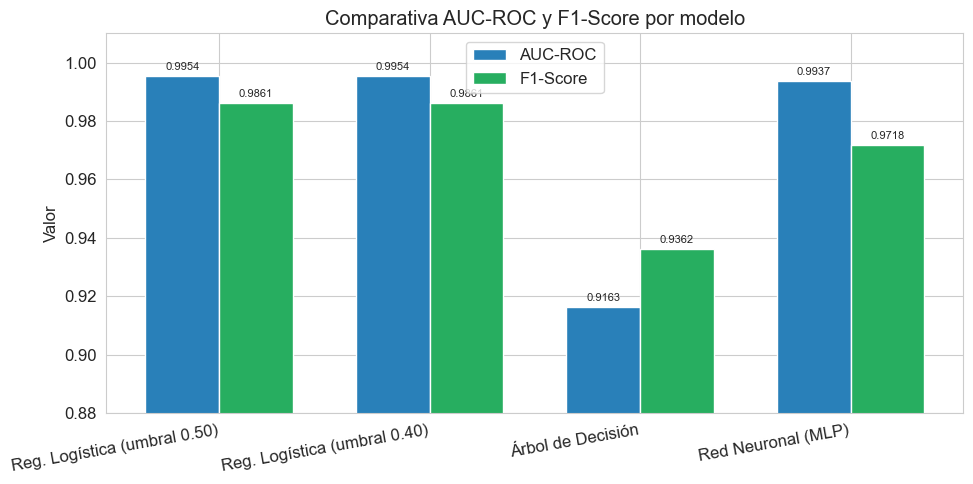

In [ ]:
# Árbol de decisión con profundidad máxima 5 para evitar sobreajuste
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

# Red neuronal MLP: dos capas ocultas (64 y 32 neuronas)
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
y_proba_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

# Regresión logística con umbral óptimo 0.40
y_pred_lr_opt = (y_proba >= 0.40).astype(int)

# Función auxiliar: calcula todas las métricas para un modelo dado
def metricas(y_true, y_pred, y_prob, nombre):
    return {
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precisión': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(y_true, y_prob), 4),
        'FN (malignos perdidos)': int(((y_true == 0) & (y_pred == 1)).sum()),
        'FP (falsas alarmas)': int(((y_true == 1) & (y_pred == 0)).sum()),
    }

# Construir tabla comparativa con los 4 modelos
comparativa = pd.DataFrame([
    metricas(y_test, y_pred_default, y_proba, 'Reg. Logística (umbral 0.50)'),
    metricas(y_test, y_pred_lr_opt, y_proba, 'Reg. Logística (umbral 0.40)'),
    metricas(y_test, y_pred_dt, y_proba_dt, 'Árbol de Decisión'),
    metricas(y_test, y_pred_mlp, y_proba_mlp, 'Red Neuronal (MLP)'),
])

print(comparativa.to_string(index=False))

# Gráfico de barras comparativo - AUC-ROC y F1-Score por modelo
modelos = comparativa['Modelo']
x = np.arange(len(modelos))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - ancho/2, comparativa['AUC-ROC'], ancho, label='AUC-ROC', color='#2980b9')
ax.bar(x + ancho/2, comparativa['F1-Score'], ancho, label='F1-Score', color='#27ae60')

# Añadir el valor numérico encima de cada barra
for i, (auc, f1) in enumerate(zip(comparativa['AUC-ROC'], comparativa['F1-Score'])):
    ax.text(i - ancho/2, auc + 0.002, str(auc), ha='center', fontsize=8)
    ax.text(i + ancho/2, f1 + 0.002, str(f1), ha='center', fontsize=8)

ax.set_xticks(x)                                                                                    
ax.set_xticklabels(modelos, rotation=10, ha='right')
ax.set_ylim(0.88, 1.01)                                                                             
ax.set_ylabel('Valor')                                                                              
ax.set_title('Comparativa AUC-ROC y F1-Score por modelo')
ax.legend()                                                                                         
plt.tight_layout()
plt.savefig('figures/fig6_comparativa_barras.png', dpi=150)                                                 
plt.show()

### Observaciones - Comparativa de modelos

La tabla y el gráfico comparan los cuatro modelos evaluados sobre el mismo conjunto de prueba (114 muestras), usando las mismas métricas para garantizar una comparación justa.

**Regresión Logística - modelo principal:**
Obtiene el AUC-ROC más alto (0.9954) y el mejor F1-Score (0.9861) con solo 1 falso negativo sobre 42 casos malignos. Las dos filas (umbral 0.50 y 0.40) muestran métricas idénticas porque ningún caso maligno tiene probabilidad entre 0.40 y 0.49. El único tumor maligno no detectado tiene probabilidad superior a 0.50. A pesar de ello, se selecciona 0.40 como umbral operativo por ser más conservador: exige mayor confianza antes de clasificar un tumor como benigno, lo que es coherente con el principio de precaución clínica.

**Árbol de Decisión - modelo de referencia inferior:**
Con AUC-ROC de 0.9163 y F1 de 0.9362 es el modelo de peor rendimiento. Comete 3 falsos negativos (el triple que la regresión logística), lo que lo descarta para un entorno clínico donde minimizar los malignos no detectados es prioritario.

**Red Neuronal MLP - modelo de referencia superior:**
Con AUC-ROC de 0.9937 y F1 de 0.9718 es competitivo pero inferior a la regresión logística en todas las métricas. Además, su mayor complejidad computacional y menor interpretabilidad lo hacen menos adecuado para un contexto médico donde explicar la decisión del modelo es tan importante como su precisión.

**Conclusión:** la regresión logística con umbral 0.40 es el modelo óptimo para este problema, combinando el mayor poder discriminativo (AUC 0.9954), el mínimo de falsos negativos alcanzable (FN=1) y la ventaja de ser un modelo interpretable.

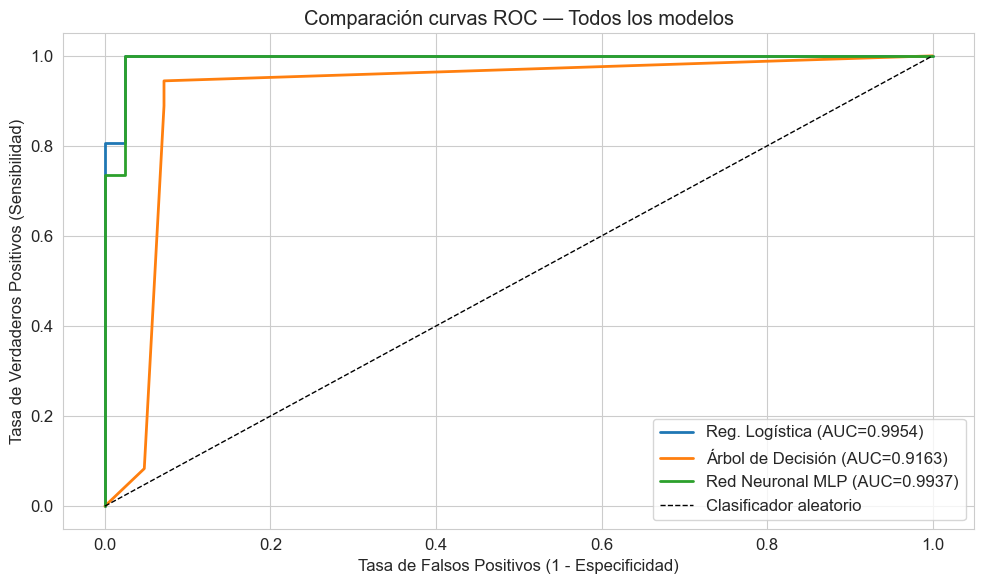

In [ ]:
# Calcular los puntos de la curva ROC para el árbol de decisión y la red neuronal
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)                                                
                  
fig, ax = plt.subplots()

# Una línea por modelo
ax.plot(fpr, tpr, linewidth=2, label=f'Reg. Logística (AUC={auc_score:.4f})')                         
ax.plot(fpr_dt, tpr_dt, linewidth=2, label=f'Árbol de Decisión (AUC={roc_auc_score(y_test, y_proba_dt):.4f})')
ax.plot(fpr_mlp, tpr_mlp, linewidth=2, label=f'Red Neuronal MLP (AUC={roc_auc_score(y_test, y_proba_mlp):.4f})')

# Diagonal de referencia: clasificador aleatorio (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')

ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Comparación curvas ROC — Todos los modelos')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig7_roc_comparativa.png', dpi=150)
plt.show()

In [14]:
# StratifiedKFold: divide el dataset en 5 partes manteniendo la proporción
# shuffle = True mezcla los datos antes de dividir para evitar sesgos por orden
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo in [('Reg. Logística', lr),
                      ('Árbol de Decisión', dt),
                      ('Red Neuronal MLP', mlp)]:
    # Aplicar el scaler a todo X y evaluar con validación cruzada
    # scoring = 'f1' usa F1 de la clase positiva (benigno) como métrica de evaluación
    scores = cross_val_score(modelo, scaler.transform(X), y, cv=cv, scoring='f1')
    # scores es un array de 5 valores
    # .mean() y .std() resumen el rendimiento medio y su variabilidad
    print(f"{nombre:25s} F1 medio: {scores.mean():.4f} +/- {scores.std():.4f}")

Reg. Logística            F1 medio: 0.9794 +/- 0.0127
Árbol de Decisión         F1 medio: 0.9438 +/- 0.0164
Red Neuronal MLP          F1 medio: 0.9807 +/- 0.0099


### Observaciones - Validación cruzada

| Modelo            | F1 medio | Desviación estándar |
|-------------------|----------|---------------------|
| Reg. Logística    | 0.9794   | ± 0.0127            |
| Red Neuronal MLP  | 0.9807   | ± 0.0099            |
| Árbol de Decisión | 0.9438   | ± 0.0164            |

Los resultados son **consistentes con los obtenidos en la partición única**, lo que confirma que las métricas no dependen de una división afortunada de los datos sino que reflejan el rendimiento real de cada modelo.

La regresión logística y la red neuronal MLP obtienen F1 medios prácticamente idénticos (0.9794 vs 0.9807), con una diferencia de apenas 0.0013 que no es estadísticamente significativa. La regresión logística presenta además una desviación estándar de ±0.0127, indicando un rendimiento estable y consistente entre las distintas particiones.

El árbol de decisión muestra la mayor variabilidad (±0.0164) además del F1 más bajo (0.9438), confirmando que es el modelo menos robusto de los tres.

**Conclusión:** la validación cruzada refuerza la elección de la regresión logística como modelo óptimo, al demostrar que su rendimiento es generalizable y no dependiente de la partición concreta de evaluación.

---

## 7. Interpretabilidad del modelo

Una de las ventajas clave de la regresión logística frente a modelos más complejos es su interpretabilidad: cada coeficiente indica el peso de una característica en la predicción final. En un contexto clínico, esto permite a los profesionales médicos entender qué variables del tumor influyen más en el diagnóstico, algo imposible con modelos de "caja negra".

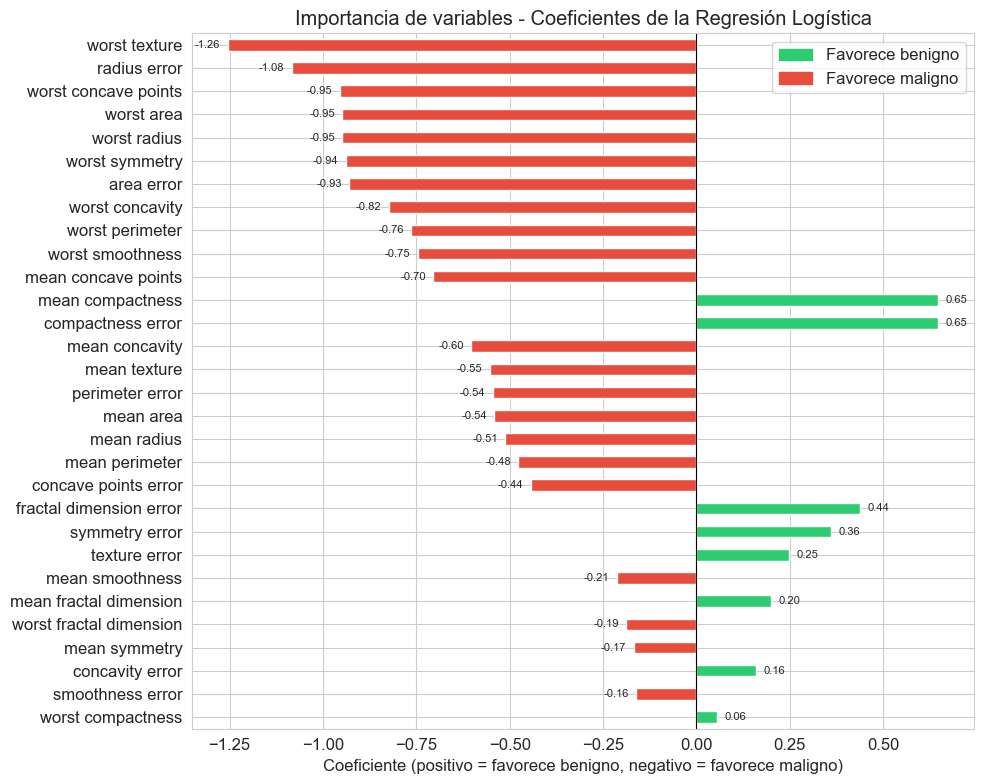

Top 5 variables con mayor peso en el diagnóstico:
worst texture                       -1.2551
radius error                        -1.0830
worst concave points                -0.9537
worst area                          -0.9478
worst radius                        -0.9476


In [ ]:
# Extraer los coeficientes del modelo base (lr)
# Nota: si el GridSearchCV de la sección 3.1 encontró una combinación distinta
# a C=1, L2, considera usar lr_opt aquí para que la interpretabilidad corresponda
# al modelo optimizado.

# coef_[0] devuelve un array 1D con un coeficiente por cada feature
# positivo = aumenta probabilidad de benigno (clase 1)
# negativo = aumenta probabilidad de maligno (clase 0)
coeficientes = pd.Series(lr.coef_[0], index=data.feature_names)

# Ordenar por valor absoluto ascendente para que la barra más larga
# quede arriba en el gráfico horizontal (mayor impacto visual)
coef_ordenados = coeficientes.reindex(
    coeficientes.abs().sort_values(ascending=True).index
)

fig, ax = plt.subplots(figsize=(10,8))

# Asignar color según el signo del coeficiente
colores = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_ordenados]
coef_ordenados.plot(kind='barh', ax=ax, color=colores)

# Línea vertical en 0 como referencia visual
ax.axvline(x=0, color='black', linewidth=0.8)

# Anotar el valor numérico al final de cada barra para facilitar la lectura
for i, (nombre, valor) in enumerate(coef_ordenados.items()):
    offset = 0.02 if valor >= 0 else -0.02
    ha = 'left' if valor >= 0 else 'right'
    ax.text(valor + offset, i, f'{valor:.2f}', va='center', ha=ha, fontsize=8)

ax.set_title('Importancia de variables - Coeficientes de la Regresión Logística')
ax.set_xlabel('Coeficiente (positivo = favorece benigno, negativo = favorece maligno)')

# Leyenda manual porque el color no viene de un objeto Line2D sino de barras individuales
leyenda = [Patch(color='#2ecc71', label='Favorece benigno'),
          Patch(color='#e74c3c', label='Favorece maligno')]
ax.legend(handles=leyenda)

plt.tight_layout()
plt.savefig('figures/fig8_interpretabilidad.png', dpi=150)
plt.show()

# Mostrar los 5 coeficientes con mayor peso, con su valor real ( no solo absoluto)
print('Top 5 variables con mayor peso en el diagnóstico:')
top5 = coeficientes.abs().sort_values(ascending=False).head(5)
for nombre in top5.index:
    print(f"{nombre:<35} {coeficientes[nombre]:+.4f}")


### Observaciones - Interpretabilidad del modelo

**Patrón general:**
22 de las 30 variables tienen coeficiente negativo, lo que significa que el modelo interpreta el aumento de la mayoría de características del tumor como indicador de malignidad. Solo 8 variables favorecen el diagnóstico benigno.

**Variables más influyentes (top 5, todas negativas):**

| Variable             | Coeficiente | Interpretación clínica                                        |
|----------------------|-------------|---------------------------------------------------------------|
| worst texture        | -1.26       | Mayor variabilidad en la textura celular → indicador maligno  |
| radius error         | -1.08       | Mayor irregularidad en el radio del tumor → indicador maligno |
| worst concave points | -0.95       | Más concavidades extremas en el contorno → indicador maligno  |
| worst area           | -0.95       | Mayor área máxima del tumor → indicador maligno               |
| worst radius         | -0.95       | Mayor radio máximo del tumor → indicador maligno              |

Las variables `worst` (valor más extremo medido entre todas las células de la imagen) dominan el ranking, lo que es coherente clínicamente: las características más extremas del tumor son las más determinantes en el diagnóstico.

**Variables con coeficiente positivo más alto:**
`mean compactness` y `compactness error` (ambas +0.65) aparecen como los mayores predictores de benignidad. Aunque la compacidad irregular puede asociarse a malignidad, en presencia del resto de variables el modelo les asigna efecto contrario. Esto es un efecto habitual de la multicolinealidad: cuando variables están correlacionadas entre sí (radio, perímetro y área miden aspectos similares del tamaño), los coeficientes individuales reflejan la contribución marginal de cada una dado el resto, y pueden invertir su signo esperado.

**Limitación importante:**
Los coeficientes no deben interpretarse de forma aislada en presencia de variables correlacionadas. Para una interpretabilidad más robusta en un entorno clínico real se recomendaría complementar este análisis con técnicas como SHAP o permutation importance.

---

## 8. Resumen de resultados

| Modelo                             | Accuracy | F1-Score | AUC-ROC | FN |
|------------------------------------|----------|----------|---------|----|
| Reg. Logística (0.50)              | 0.9825   | 0.9861   | 0.9954  | 1  |
| Reg. Logística (0.40)              | 0.9825   | 0.9861   | 0.9954  | 1  |
| GridSearchCV F1 (C=0.1, L2)        | 0.9737   | -        | -       | 2  |
| GridSearchCV clínico (C=0.001, L1) | 0.3684   | -        | -       | 0  |
| Árbol de Decisión                  | 0.9211   | 0.9362   | 0.9163  | 3  |
| Red Neuronal MLP                   | 0.9649   | 0.9718   | 0.9937  | 1  |

**Conclusión:** 

La regresión logística con umbral 0.40 es el modelo óptimo para entornos clínicos por tres razones:

- **Mejor capacidad discriminativa:** AUC-ROC de 0.9954, el más alto de los modelos evaluados.
- **Mínimo de falsos negativos alcanzable:** solo 1 maligno no detectado sobre 42 casos (2.38%).
- **Resultados generalizables:** la validación cruzada (F1 medio 0.9794 ± 0.0127) confirma que el rendimiento es estable y no dependiente de la partición de evaluación.

El ajuste del umbral de 0.50 a 0.40 no altera las métricas en este dataset -ambos valores caen en rango óptimo- pero es la elección clínicamente correcta: opera en el límite inferior del intervalo donde los FN son mínimos, maximizando la superficie de detección dentro del umbral viable.